<a href="https://colab.research.google.com/github/Satheesparrow/geo-ai-environmental-monitor/blob/main/geo_ai_environmental_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geo AI — Environmental Monitoring
### Satellite-based fire detection and vegetation analysis using Google Earth Engine and Groq AI

**Data sources:** NASA FIRMS (VIIRS), Google Earth Engine (Sentinel-2)  
**AI layer:** Groq (Llama 3.3)  
**Region:** Sri Lanka  
**Author:** Satheesparrow


In [1]:
# ── Install libraries not available by default in Colab ──
!pip install earthengine-api geemap groq folium --quiet

# ── Imports ──
import ee
import geemap
import folium
import requests
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

print("All libraries loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.9 MB/s eta 0:00:00
All libraries loaded successfully


In [2]:
# ── Load API keys from Colab Secrets ──
firms_key = userdata.get('FIRMS_API_KEY')
groq_key  = userdata.get('GROQ_API_KEY')

# ── Authenticate Google Earth Engine ──
ee.Authenticate()   # opens a browser popup — sign in with your Google account
ee.Initialize(project='my-ee-project-470612')  # replace with your actual GCP project ID

print("GEE authenticated successfully")
print(f"FIRMS key loaded: {'yes' if firms_key else 'NO - check Colab Secrets'}")
print(f"Groq key loaded:  {'yes' if groq_key else 'NO - check Colab Secrets'}")

GEE authenticated successfully
FIRMS key loaded: yes
Groq key loaded:  yes


# Geo AI — Environmental Monitoring
### Fire detection & vegetation analysis | Google Earth Engine + Groq AI
**Region:** Sri Lanka | **Data:** NASA FIRMS + Sentinel-2 | **AI:** Groq Llama 3.3

In [3]:
# Install required libraries
!pip install earthengine-api geemap groq folium --quiet
print("Installation complete")

Installation complete


## Step 1 — Import libraries

In [4]:
import ee
import geemap
import folium
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime, timedelta
from google.colab import userdata
from groq import Groq

print("All imports successful")
print(f"Date today: {datetime.now().strftime('%Y-%m-%d')}")

All imports successful
Date today: 2026-04-21


## Step 2 — Authentication & API keys

In [5]:
# ── Load secrets ──
firms_key = userdata.get('FIRMS_API_KEY')
groq_key  = userdata.get('GROQ_API_KEY')

print(f"FIRMS key loaded : {'YES' if firms_key else 'MISSING - check Colab Secrets'}")
print(f"Groq key loaded  : {'YES' if groq_key  else 'MISSING - check Colab Secrets'}")

# ── Authenticate Google Earth Engine ──
# This opens a popup - sign in with your Google account and paste the code back
ee.Authenticate()
ee.Initialize(project='my-ee-project-470612')  # replace with your GCP project ID

print("\nGEE authenticated and ready")

FIRMS key loaded : YES
Groq key loaded  : YES

GEE authenticated and ready


## Step 3 — Define study area (Sri Lanka)

In [6]:
# ── Sri Lanka bounding box ──
STUDY_AREA = {
    'name'  : 'Sri Lanka',
    'west'  : 79.5,
    'south' : 5.9,
    'east'  : 81.9,
    'north' : 9.8
}

# ── Date range — last 30 days ──
END_DATE   = datetime.now().strftime('%Y-%m-%d')
START_DATE = (datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')

print(f"Study area : {STUDY_AREA['name']}")
print(f"Bounding box : {STUDY_AREA['west']}, {STUDY_AREA['south']}, "
      f"{STUDY_AREA['east']}, {STUDY_AREA['north']}")
print(f"Date range : {START_DATE} to {END_DATE}")

# ── GEE geometry for the study area ──
roi = ee.Geometry.Rectangle([
    STUDY_AREA['west'],
    STUDY_AREA['south'],
    STUDY_AREA['east'],
    STUDY_AREA['north']
])
print("\nGEE region of interest defined")

Study area : Sri Lanka
Bounding box : 79.5, 5.9, 81.9, 9.8
Date range : 2026-03-22 to 2026-04-21

GEE region of interest defined


## Step 4 — Acquire fire hotspot data (NASA FIRMS)

In [7]:
def fetch_firms_data(api_key, area, days=5, source='VIIRS_SNPP_NRT'):
    """
    Fetch fire hotspot data from NASA FIRMS API.
    Area endpoint supports max 5 days.
    For longer ranges we loop and combine.
    """
    bbox = f"{area['west']},{area['south']},{area['east']},{area['north']}"

    # ── If days <= 5, single request ──
    if days <= 5:
        url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{api_key}/{source}/{bbox}/{days}"
        print(f"Fetching {days} days of data...")
        response = requests.get(url, timeout=30)

        if response.status_code == 200:
            from io import StringIO
            df = pd.read_csv(StringIO(response.text))
            print(f"Success — {len(df)} fire hotspots retrieved")
            return df
        else:
            print(f"Error {response.status_code}: {response.text[:200]}")
            return pd.DataFrame()

    # ── If days > 5, use date-based endpoint in 5-day chunks ──
    else:
        from io import StringIO
        all_dfs = []
        end   = datetime.now()
        start = end - timedelta(days=days)

        current_end = end
        print(f"Fetching {days} days in chunks of 5...")

        while current_end > start:
            current_start = max(current_end - timedelta(days=5), start)
            date_str      = current_start.strftime('%Y-%m-%d')

            # date-based URL format
            url = (f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
                   f"{api_key}/{source}/{bbox}/5/{date_str}")

            response = requests.get(url, timeout=30)

            if response.status_code == 200:
                try:
                    chunk = pd.read_csv(StringIO(response.text))
                    if not chunk.empty:
                        all_dfs.append(chunk)
                        print(f"  Chunk {date_str}: {len(chunk)} hotspots")
                except Exception as e:
                    print(f"  Chunk {date_str}: parse error — {e}")
            else:
                print(f"  Chunk {date_str}: Error {response.status_code}")

            current_end = current_start
            time.sleep(0.5)  # be polite to the API

        if all_dfs:
            df = pd.concat(all_dfs, ignore_index=True)
            df = df.drop_duplicates()
            print(f"\nTotal: {len(df)} hotspots over {days} days")
            return df
        else:
            print("No data retrieved")
            return pd.DataFrame()


# ── Add this import at the top of the cell ──
import time

# ── Run with 5 days (safe) or 30 days (chunked) ──
fire_df = fetch_firms_data(firms_key, STUDY_AREA, days=5)

# ── Preview ──
if not fire_df.empty:
    print(f"\nColumns : {list(fire_df.columns)}")
    print(f"\nFirst 3 rows:")
    display(fire_df.head(3))
else:
    print("No fire data returned — Sri Lanka may have no active fires right now")
    print("Try increasing days or check your API key")

Fetching 5 days of data...
Success — 57 fire hotspots retrieved

Columns : ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight']

First 3 rows:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,7.62207,81.03232,335.34,0.63,0.72,2026-04-17,714,N,VIIRS,n,2.0NRT,297.31,3.64,D
1,8.09593,81.37794,332.91,0.58,0.70,2026-04-17,714,N,VIIRS,n,2.0NRT,299.36,8.18,D
2,7.65387,80.49086,330.86,0.56,0.51,2026-04-18,837,N,VIIRS,n,2.0NRT,299.91,4.09,D


## Step 5 — Explore fire data

In [8]:
if not fire_df.empty:
    print("=== Fire Data Summary ===")
    print(f"Total hotspots      : {len(fire_df)}")
    print(f"Date range          : {fire_df['acq_date'].min()} to {fire_df['acq_date'].max()}")

    if 'confidence' in fire_df.columns:
        print(f"\nConfidence breakdown:")
        print(fire_df['confidence'].value_counts().to_string())

    if 'frp' in fire_df.columns:
        print(f"\nFire Radiative Power (MW):")
        print(f"  Mean   : {fire_df['frp'].mean():.2f}")
        print(f"  Max    : {fire_df['frp'].max():.2f}")
        print(f"  Median : {fire_df['frp'].median():.2f}")

    # Daily hotspot count
    daily = fire_df.groupby('acq_date').size().reset_index(name='count')
    print(f"\nDaily counts (last 5 days):")
    print(daily.tail(5).to_string(index=False))
else:
    print("No fire data — check your FIRMS API key and bounding box")

=== Fire Data Summary ===
Total hotspots      : 57
Date range          : 2026-04-17 to 2026-04-21

Confidence breakdown:
confidence
n    40
l    17

Fire Radiative Power (MW):
  Mean   : 5.65
  Max    : 14.04
  Median : 5.55

Daily counts (last 5 days):
  acq_date  count
2026-04-17      2
2026-04-18      8
2026-04-19     24
2026-04-20     18
2026-04-21      5


## Step 6 — Visualize fire hotspot trends

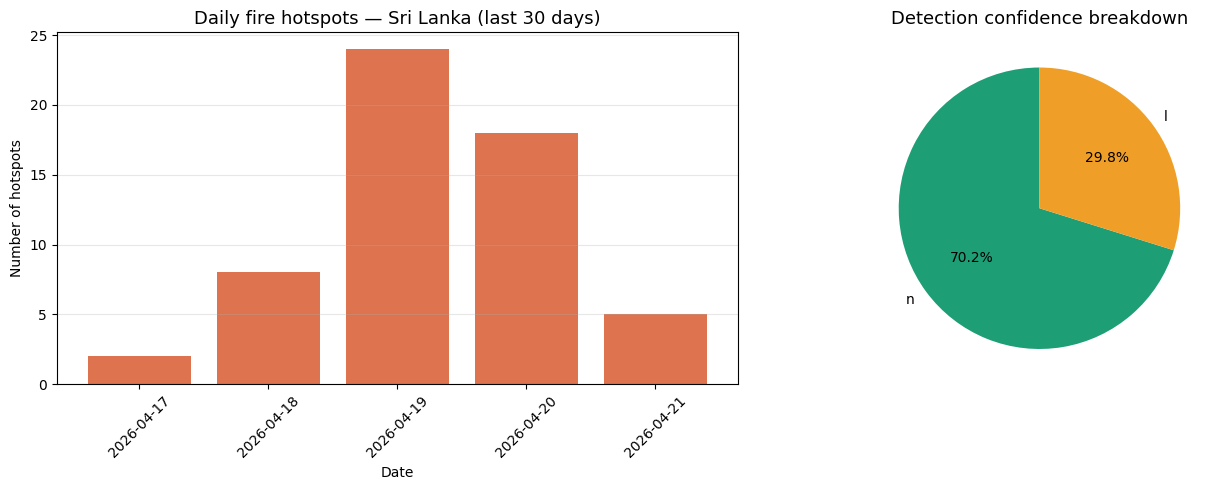

Chart saved as fire_trends.png


In [9]:
if not fire_df.empty:
    daily = fire_df.groupby('acq_date').size().reset_index(name='count')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Chart 1: Daily hotspot count ──
    axes[0].bar(daily['acq_date'], daily['count'], color='#D85A30', alpha=0.85)
    axes[0].set_title('Daily fire hotspots — Sri Lanka (last 30 days)', fontsize=13)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Number of hotspots')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

    # ── Chart 2: Confidence distribution ──
    if 'confidence' in fire_df.columns:
        conf_counts = fire_df['confidence'].value_counts()
        colors = ['#1D9E75', '#EF9F27', '#D85A30']
        axes[1].pie(conf_counts.values, labels=conf_counts.index,
                    colors=colors[:len(conf_counts)],
                    autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Detection confidence breakdown', fontsize=13)

    plt.tight_layout()
    plt.savefig('fire_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved as fire_trends.png")

## Step 7 — Vegetation health analysis (NDVI from Sentinel-2)

In [10]:
def get_ndvi_image(roi, start_date, end_date):
    """Get median NDVI from Sentinel-2 for the given period."""

    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(roi)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .map(lambda img: img.normalizedDifference(['B8', 'B4'])
                               .rename('NDVI')
                               .copyProperties(img, ['system:time_start'])))

    ndvi_median = s2.median().clip(roi)
    print(f"NDVI image computed for {start_date} to {end_date}")
    return ndvi_median

# ── Compute NDVI ──
ndvi = get_ndvi_image(roi, START_DATE, END_DATE)

# ── Get mean NDVI statistic ──
mean_ndvi = ndvi.reduceRegion(
    reducer   = ee.Reducer.mean(),
    geometry  = roi,
    scale     = 1000,
    maxPixels = 1e9
).getInfo()

print(f"\nMean NDVI for Sri Lanka ({START_DATE} to {END_DATE}):")
print(f"  NDVI = {mean_ndvi['NDVI']:.4f}")
print("\nNDVI interpretation:")
print("  < 0.2  = bare soil / urban")
print("  0.2–0.4 = sparse vegetation")
print("  0.4–0.6 = moderate vegetation")
print("  > 0.6  = dense forest / healthy vegetation")

NDVI image computed for 2026-03-22 to 2026-04-21

Mean NDVI for Sri Lanka (2026-03-22 to 2026-04-21):
  NDVI = 0.3020

NDVI interpretation:
  < 0.2  = bare soil / urban
  0.2–0.4 = sparse vegetation
  0.4–0.6 = moderate vegetation
  > 0.6  = dense forest / healthy vegetation


## Step 8 — Interactive map (fire hotspots + NDVI)

In [11]:
# ── Create base map centered on Sri Lanka ──
center_lat = (STUDY_AREA['south'] + STUDY_AREA['north']) / 2
center_lon = (STUDY_AREA['west']  + STUDY_AREA['east'])  / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=7,
               tiles='CartoDB positron')

# ── Add fire hotspots as circle markers ──
if not fire_df.empty:
    # Color by confidence
    conf_color = {'high': '#D85A30', 'nominal': '#EF9F27', 'low': '#FAC775'}

    for _, row in fire_df.iterrows():
        color = conf_color.get(
            str(row.get('confidence', 'nominal')).lower(), '#EF9F27'
        )
        folium.CircleMarker(
            location  = [row['latitude'], row['longitude']],
            radius    = max(3, row.get('frp', 5) / 10),
            color     = color,
            fill      = True,
            fill_color= color,
            fill_opacity=0.7,
            popup     = folium.Popup(
                f"Date: {row['acq_date']}<br>"
                f"FRP: {row.get('frp', 'N/A')} MW<br>"
                f"Confidence: {row.get('confidence', 'N/A')}",
                max_width=200
            )
        ).add_to(m)

# ── Add study area boundary ──
folium.Rectangle(
    bounds    = [[STUDY_AREA['south'], STUDY_AREA['west']],
                 [STUDY_AREA['north'], STUDY_AREA['east']]],
    color     = '#185FA5',
    fill      = False,
    weight    = 2,
    dash_array= '5 5'
).add_to(m)

# ── Legend ──
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px; border-radius:8px;
     border:1px solid #ccc; font-size:13px;">
  <b>Fire hotspot confidence</b><br>
  <span style="color:#D85A30;">&#9679;</span> High<br>
  <span style="color:#EF9F27;">&#9679;</span> Nominal<br>
  <span style="color:#FAC775;">&#9679;</span> Low<br>
  <i>Circle size = Fire Radiative Power</i>
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Display map ──
print(f"Map created with {len(fire_df)} fire hotspots")
m.save('fire_map.html')
display(m)

Map created with 57 fire hotspots


## Step 9 — AI-generated environmental report (Groq)

In [12]:
def generate_report(fire_df, mean_ndvi, study_area, start_date, end_date):
    """Use Groq AI to generate a natural language environmental report."""

    client = Groq(api_key=groq_key)

    # ── Build data summary to send to AI ──
    if not fire_df.empty:
        daily_counts = fire_df.groupby('acq_date').size()
        high_conf    = len(fire_df[fire_df.get('confidence', pd.Series()).str.lower() == 'high']) \
                       if 'confidence' in fire_df.columns else 'N/A'
        max_frp      = fire_df['frp'].max() if 'frp' in fire_df.columns else 'N/A'
        peak_day     = daily_counts.idxmax() if not daily_counts.empty else 'N/A'
        peak_count   = daily_counts.max()    if not daily_counts.empty else 0
    else:
        high_conf = max_frp = peak_day = 'N/A'
        peak_count = 0

    ndvi_val = mean_ndvi.get('NDVI', 0)

    prompt = f"""You are an environmental monitoring analyst.
Write a concise professional report (150–200 words) based on this satellite data:

STUDY AREA: {study_area['name']}
PERIOD: {start_date} to {end_date}

FIRE DATA (NASA FIRMS VIIRS):
- Total fire hotspots detected: {len(fire_df)}
- High confidence detections: {high_conf}
- Peak activity: {peak_count} hotspots on {peak_day}
- Maximum fire radiative power: {max_frp} MW

VEGETATION DATA (Sentinel-2 NDVI):
- Mean NDVI: {ndvi_val:.4f}
- Interpretation: {'dense/healthy vegetation' if ndvi_val > 0.6
                   else 'moderate vegetation' if ndvi_val > 0.4
                   else 'sparse vegetation' if ndvi_val > 0.2
                   else 'bare/degraded land'}

Write the report with: an executive summary, key findings,
environmental implications, and one recommendation.
Use plain professional English. No bullet points."""

    response = client.chat.completions.create(
        model    = 'llama-3.3-70b-versatile',
        messages = [{'role': 'user', 'content': prompt}],
        max_tokens= 400
    )

    return response.choices[0].message.content

# ── Generate and display the report ──
print("Generating AI environmental report...\n")
report = generate_report(fire_df, mean_ndvi, STUDY_AREA, START_DATE, END_DATE)

print("=" * 60)
print("  GEO AI ENVIRONMENTAL MONITORING REPORT")
print("=" * 60)
print(report)
print("=" * 60)

Generating AI environmental report...

  GEO AI ENVIRONMENTAL MONITORING REPORT
Executive Summary: 
This report presents an analysis of satellite data for Sri Lanka, covering the period from 2026-03-22 to 2026-04-21. The data includes fire hotspots detected by NASA FIRMS VIIRS and vegetation health indicated by Sentinel-2 NDVI.

Key Findings: 
The analysis revealed a total of 57 fire hotspots, with the peak activity occurring on 2026-04-19, where 24 hotspots were detected. The maximum fire radiative power was recorded at 14.04 MW. The mean NDVI value of 0.3020 indicates sparse vegetation across the study area.

Environmental Implications: 
The presence of fire hotspots, particularly with sparse vegetation, suggests a potential risk of wildfires and degradation of natural habitats. This could have adverse effects on local biodiversity and ecosystem services.

Recommendation: 
We recommend that the relevant authorities closely monitor the fire hotspot areas and consider implementing fire

## Step 10 — Save all outputs

In [13]:
from google.colab import files
import json

# ── Save report as text file ──
with open('environmental_report.txt', 'w') as f:
    f.write(f"GEO AI ENVIRONMENTAL MONITORING REPORT\n")
    f.write(f"{'='*50}\n")
    f.write(f"Area      : {STUDY_AREA['name']}\n")
    f.write(f"Period    : {START_DATE} to {END_DATE}\n")
    f.write(f"Generated : {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"{'='*50}\n\n")
    f.write(report)

# ── Save fire data as CSV ──
if not fire_df.empty:
    fire_df.to_csv('fire_hotspots.csv', index=False)
    print(f"fire_hotspots.csv saved — {len(fire_df)} rows")

print("environmental_report.txt saved")
print("fire_trends.png saved")
print("fire_map.html saved")

# ── Summary stats ──
print(f"\n{'='*40}")
print(f"PROJECT SUMMARY")
print(f"{'='*40}")
print(f"Study area     : {STUDY_AREA['name']}")
print(f"Period         : {START_DATE} to {END_DATE}")
print(f"Fire hotspots  : {len(fire_df)}")
print(f"Mean NDVI      : {mean_ndvi.get('NDVI', 0):.4f}")
print(f"Outputs saved  : 4 files")
print(f"{'='*40}")

fire_hotspots.csv saved — 57 rows
environmental_report.txt saved
fire_trends.png saved
fire_map.html saved

PROJECT SUMMARY
Study area     : Sri Lanka
Period         : 2026-03-22 to 2026-04-21
Fire hotspots  : 57
Mean NDVI      : 0.3020
Outputs saved  : 4 files


## Step 11 — Save notebook to GitHub

In [14]:
# This cell is just a reminder — no code to run
print("To save this notebook to GitHub:")
print("1. Click File in the top menu")
print("2. Click 'Save a copy in GitHub'")
print("3. Select repo: geo-ai-environmental-monitor")
print("4. File path: notebooks/geo_ai_environmental_monitor.ipynb")
print("5. Commit message: 'Add complete environmental monitoring notebook'")
print("6. Click OK")
print("\nYour project will be live on GitHub!")

To save this notebook to GitHub:
1. Click File in the top menu
2. Click 'Save a copy in GitHub'
3. Select repo: geo-ai-environmental-monitor
4. File path: notebooks/geo_ai_environmental_monitor.ipynb
5. Commit message: 'Add complete environmental monitoring notebook'
6. Click OK

Your project will be live on GitHub!
